# PER·PBR 가치주 스크리닝 — 02. 싼 주식을 데이터로 찾아보기

[01번](./01-kospi-market-explorer.ipynb)에서 시세·지수를 봤다면, 이번엔 **재무제표**로
"이 주식이 싼가"를 따져본다. 목적은 여전히 세 가지다.

1. **Python 개발자가 TypeScript/Deno에 익숙해지기** — 이번 노트북의 새 개념은
   `Object.groupBy`(ES2024)다.
2. **주식 개념을 데이터로 체감하기** — PER·PBR이 뭔지, 왜 낮다고 무조건 좋은 게 아닌지
   ([`stock-financials-per-pbr.md`](../docs/learning/stock-financials-per-pbr.md)).
3. **여러 데이터셋의 관계를 파악하기** — 시세(`market-snapshot.json`)와 재무제표
   (`financials.json`)는 서로 다른 키(종목코드 vs 법인등록번호)를 쓴다. 이걸 **조인**하는
   과정 자체가 이번 노트북의 핵심이다.

## 데이터 출처

- `src/data/stock-master.json` — 종목코드 ↔ 법인등록번호(`crno`) 매핑
- `src/data/financials.json` — 3개년 요약재무제표(연 1회 갱신 시드, 법인등록번호로 조인)
- `src/data/market-snapshot.json` — 최근 영업일 시가총액

01번과 마찬가지로 커밋된 시드만 쓴다 — API 키 없이, 오프라인에서도 항상 같은 결과가
나온다. 실행 방법은 01번과 동일: **`notes/` 폴더 안에서** 이 파일을 열고 커널을
**Deno**로 선택 후 **Restart Kernel and Run All Cells**.

> `deno jupyter` 커널은 Deno 스스로 "실험적(unstable)"이라 표시하는 기능이라, 드물게
> 셀 출력(표·차트뿐 아니라 `console.log` 텍스트도)이 에러 없이 비어 보일 때가 있다 —
> **그 셀만 다시 실행**하면 대부분 바로 나온다.

## 1. 새 JS 개념 — `Object.groupBy`

Python 이라면 `itertools.groupby`(정렬 필요)나 `pandas.DataFrame.groupby()`를 썼을 자리다.
JS는 오랫동안 이걸 위한 표준 함수가 없어서 다들 `reduce`로 직접 짰는데, **2024년에야**
`Object.groupBy`가 표준에 들어왔다 — 최신 Deno에는 이미 있다. 키 함수가 반환한 값별로
배열을 묶어 "그룹 이름 → 그 그룹에 속한 항목 배열" 객체를 만들어준다.

In [1]:
const numbers = [1, 2, 3, 4, 5, 6];
const byParity = Object.groupBy(numbers, (n) => (n % 2 === 0 ? "even" : "odd"));
console.log(byParity); // Python: {"even": [...], "odd": [...]} (itertools.groupby는 정렬 전제라 이쪽이 더 가깝다)

[Object: null prototype] { odd: [ 1, 3, 5 ], even: [ 2, 4, 6 ] }


## 2. 세 데이터셋 조인 — 종목코드 → 법인등록번호 → 재무제표

시세는 **종목코드**(`005930`)로 식별되지만, 재무제표·기업개요는 **법인등록번호**(`crno`)로
식별된다 — 발행 주체(법인)는 하나인데 보통주·우선주 두 종목코드로 상장되는 경우가 있어서다
(`docs/api-reference.md` 2절). `stock-master.json`이 이 둘을 잇는 다리다.

**우선주는 이번 스크리닝에서 뺀다.** 우선주(예: 삼성전자우 `005935`)는 법인은 같아도
시가총액·배당이 보통주와 달라서, 법인 전체의 순이익·자본을 우선주 하나의 시총과 나누면
왜곡된 숫자가 나온다. 이 저장소의 실제 종목 상세 화면(`CompanyReport.tsx`)도 종목코드
끝자리가 `"0"`인 보통주에서만 PER·PBR을 계산한다 — 그 관례를 그대로 따른다.

In [2]:
/** {fields, rows} 형태를 필드명 키를 가진 객체 배열로 복원한다. (01번과 동일 헬퍼) */
function rowsToObjects<Field extends string>(
  fields: readonly Field[],
  rows: readonly (string | number)[][],
): Record<Field, string | number>[] {
  return rows.map((row) => {
    const obj = {} as Record<Field, string | number>;
    fields.forEach((field, i) => {
      obj[field] = row[i];
    });
    return obj;
  });
}

const stockMasterJson = JSON.parse(await Deno.readTextFile("../src/data/stock-master.json"));
const financialsJson = JSON.parse(await Deno.readTextFile("../src/data/financials.json"));
const snapshotJson = JSON.parse(await Deno.readTextFile("../src/data/market-snapshot.json"));

type MasterRow = { code: string; name: string; crno: string };
const master = rowsToObjects<keyof MasterRow>(stockMasterJson.fields, stockMasterJson.rows) as MasterRow[];
const crnoByCode = new Map(master.map((m) => [m.code, m.crno]));
const nameByCode = new Map(master.map((m) => [m.code, m.name]));

type FinYear = { crno: string; bizYear: string; sale: number; bzopPft: number; crtmNpf: number; tast: number; tdbt: number; tcpt: number };
const summaries = rowsToObjects<keyof FinYear>(financialsJson.summaryFields, financialsJson.summaries) as FinYear[];

// crno별로 묶은 뒤, 사업연도 내림차순으로 정렬 — years[0]이 최신 연도
const byCrno = Object.groupBy(summaries, (row) => row.crno);
const yearsByCrno = new Map<string, FinYear[]>();
for (const [crno, rows] of Object.entries(byCrno)) {
  yearsByCrno.set(crno, [...(rows ?? [])].sort((a, b) => b.bizYear.localeCompare(a.bizYear)));
}

console.log(`종목 마스터 ${master.length}건, 재무제표 보유 법인 ${yearsByCrno.size}곳`);

종목 마스터 943건, 재무제표 보유 법인 781곳


In [3]:
type Quote = { code: string; clpr: number; fltRt: number; mrktTotAmt: number };
const latestDay = snapshotJson.days.at(-1);
const quotes = rowsToObjects<keyof Quote>(latestDay.fields, latestDay.rows) as Quote[];

interface Screened {
  code: string;
  name: string;
  cap: number;
  years: FinYear[]; // 최신 연도부터 내림차순
}

const screenable: Screened[] = [];
let prefExcluded = 0;
let noFinancials = 0;

for (const q of quotes) {
  if (!q.code.endsWith("0")) {
    prefExcluded++; // 우선주 제외
    continue;
  }
  const crno = crnoByCode.get(q.code);
  const years = crno ? yearsByCrno.get(crno) : undefined;
  if (!years || years.length === 0) {
    noFinancials++;
    continue;
  }
  screenable.push({ code: q.code, name: nameByCode.get(q.code) ?? q.code, cap: q.mrktTotAmt, years });
}

console.log(`시세 ${quotes.length}종목 중 우선주 ${prefExcluded}종목 제외, 재무 미매칭 ${noFinancials}종목 제외`);
console.log(`→ PER·PBR 계산 대상 보통주 ${screenable.length}종목`);

시세 942종목 중 우선주 110종목 제외, 재무 미매칭 51종목 제외


→ PER·PBR 계산 대상 보통주 781종목


## 3. PER·PBR 계산

```
PER = 시가총액 ÷ 당기순이익      "지금 버는 속도로 몇 년 벌면 회사값이 되나"
PBR = 시가총액 ÷ 자본총계        "장부상 순자산 대비 몇 배에 거래되나"
```

발행주식수를 몰라도 된다 — 주가÷EPS 든 시가총액÷순이익이든 발행주식수가 분자·분모에서
약분돼 같은 값이 나온다(`시가총액 = 주가 × 발행주식수`, `EPS = 순이익 ÷ 발행주식수`이므로).

**적자 기업은 PER이 안 나온다.** 당기순이익이 0 이하면 PER은 음수거나 정의가 안 되는
숫자라 계산 자체를 뺀다 — 실제 종목 상세 화면도 이럴 때 "적자"라고만 표시한다. 자본잠식
(자본총계 ≤ 0)도 PBR을 뺀다. 이 두 원칙을 그대로 따른다.

In [4]:
interface Valuation {
  code: string;
  name: string;
  per: number | null;
  pbr: number | null;
  years: FinYear[];
}

const valuations: Valuation[] = screenable.map((s) => {
  const latest = s.years[0];
  const per = latest.crtmNpf > 0 ? s.cap / latest.crtmNpf : null;
  const pbr = latest.tcpt > 0 ? s.cap / latest.tcpt : null;
  return { code: s.code, name: s.name, per, pbr, years: s.years };
});

const deficitCount = valuations.filter((v) => v.per === null).length;
const capitalImpairedCount = valuations.filter((v) => v.pbr === null).length;

const summaryMd = `
| | 종목 수 |
|---|---|
| PER 계산 가능 (흑자) | ${valuations.length - deficitCount} |
| PER 계산 불가 (적자) | ${deficitCount} |
| PBR 계산 가능 | ${valuations.length - capitalImpairedCount} |
| PBR 계산 불가 (자본잠식) | ${capitalImpairedCount} |
`;
await Deno.jupyter.display({ "text/markdown": summaryMd }, { raw: true });


| | 종목 수 |
|---|---|
| PER 계산 가능 (흑자) | 574 |
| PER 계산 불가 (적자) | 207 |
| PBR 계산 가능 | 778 |
| PBR 계산 불가 (자본잠식) | 3 |


## 4. 분포 보기

PER·PBR 모두 극단치가 있다(적자 직전이라 이익이 거의 0에 가까운 회사는 PER이 수백~수만
배로 튄다). 히스토그램은 대다수가 몰린 구간만 보이게 범위를 자르고, 잘려나간 개수를
알려준다.

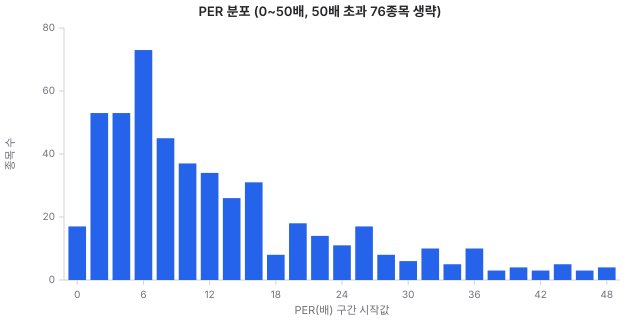

In [5]:
import { renderBarChart, COLORS } from "./lib/chart.ts";

function bucketize(values: number[], binSize: number, max: number) {
  // 정수 배수로 구간 경계를 계산한다 — `lo += binSize`로 실수를 누적하면
  // 0.2 같은 값은 이진 부동소수점으로 딱 안 떨어져서 "1.5999999999999998" 같은
  // 라벨이 새어나온다(01번 CLAUDE.md 교훈: 돈 계산도 정수로 하는 이유와 같은 함정).
  const binCount = Math.round(max / binSize);
  const bins: { label: string; value: number }[] = [];
  for (let i = 0; i < binCount; i++) {
    const lo = Number((i * binSize).toFixed(10));
    const hi = lo + binSize;
    const count = values.filter((v) => v >= lo && v < hi).length;
    bins.push({ label: `${lo}`, value: count });
  }
  return bins;
}

const pers = valuations.map((v) => v.per).filter((v): v is number => v !== null);
const perMax = 50;
const perOutliers = pers.filter((v) => v >= perMax).length;
const perSvg = renderBarChart(bucketize(pers, 2, perMax), {
  title: `PER 분포 (0~${perMax}배, ${perMax}배 초과 ${perOutliers}종목 생략)`,
  xLabel: "PER(배) 구간 시작값",
  yLabel: "종목 수",
  color: () => COLORS.down,
});
await Deno.jupyter.display({ "image/svg+xml": perSvg }, { raw: true });

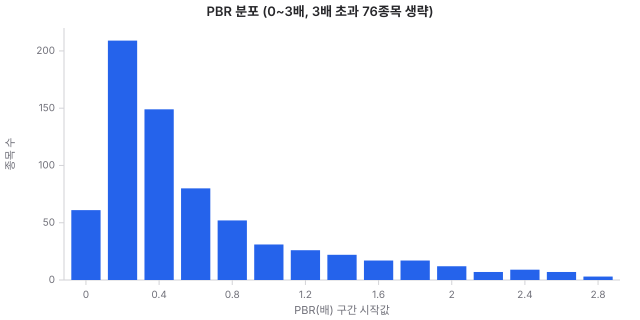

PER 중앙값 12.4배, PBR 중앙값 0.55배


In [6]:
const pbrs = valuations.map((v) => v.pbr).filter((v): v is number => v !== null);
const pbrMax = 3;
const pbrOutliers = pbrs.filter((v) => v >= pbrMax).length;
const pbrSvg = renderBarChart(bucketize(pbrs, 0.2, pbrMax), {
  title: `PBR 분포 (0~${pbrMax}배, ${pbrMax}배 초과 ${pbrOutliers}종목 생략)`,
  xLabel: "PBR(배) 구간 시작값",
  yLabel: "종목 수",
  color: () => COLORS.down,
});
await Deno.jupyter.display({ "image/svg+xml": pbrSvg }, { raw: true });

const median = (arr: number[]) => [...arr].sort((a, b) => a - b)[Math.floor(arr.length / 2)];
console.log(`PER 중앙값 ${median(pers).toFixed(1)}배, PBR 중앙값 ${median(pbrs).toFixed(2)}배`);

## 5. PER과 PBR의 관계

이익 대비로도 싸고(낮은 PER) 순자산 대비로도 싼(낮은 PBR) 종목은 산점도 **왼쪽 아래**에
몰린다. 둘 다 만족하는 종목(아래 6절 스크리닝 기준)을 다른 색으로 강조한다.

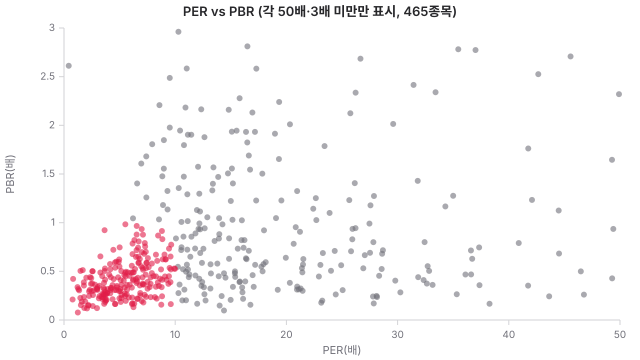

In [7]:
import { renderScatterChart } from "./lib/chart.ts";

const PER_LIMIT = 10;
const PBR_LIMIT = 1;

const both = valuations.filter((v) => v.per !== null && v.pbr !== null && v.per < perMax && v.pbr < pbrMax);
const scatterSvg = renderScatterChart(
  both.map((v) => ({
    x: v.per!,
    y: v.pbr!,
    label: `${v.name} (PER ${v.per!.toFixed(1)} / PBR ${v.pbr!.toFixed(2)})`,
  })),
  {
    title: `PER vs PBR (각 ${perMax}배·${pbrMax}배 미만만 표시, ${both.length}종목)`,
    xLabel: "PER(배)",
    yLabel: "PBR(배)",
    color: (p) => (p.x < PER_LIMIT && p.y < PBR_LIMIT ? COLORS.up : COLORS.neutral),
  },
);
await Deno.jupyter.display({ "image/svg+xml": scatterSvg }, { raw: true });

## 6. 가치주 스크리닝 — 그리고 함정

**기준: PER 10배 미만 & PBR 1배 미만.** 흔히 쓰이는 "쌈"의 대략적인 기준값이다(정답은
아니다 — 업종·시기마다 다르다). 다만 여기서 멈추지 않는다. 이 문서가 짚은 대로,

&gt; "분모(이익·자본)는 **과거** 숫자고 주가는 **미래**를 반영한다. 싸 보이는 데는 대개
&gt; 이유가 있다" — 이익이 계속 줄어드는 회사라서 쌀 수도 있다(**가치 함정**).

그래서 표에 **최근 3개년 순이익 추세**를 같이 보여준다 — PER이 낮아도 순이익이 매년
줄고 있다면, "싸다"가 아니라 "싸질 이유가 있다"일 수 있다.

In [8]:
function krwCompact(won: number): string {
  const sign = won < 0 ? "-" : "";
  const abs = Math.abs(won);
  if (abs >= 1_0000_0000_0000) return `${sign}${(abs / 1_0000_0000_0000).toFixed(1)}조`;
  if (abs >= 1_0000_0000) return `${sign}${Math.round(abs / 1_0000_0000)}억`;
  return `${sign}${abs}`;
}

function profitTrend(years: FinYear[]): string {
  // years는 최신→과거 순 — 오래된 것부터 읽히게 뒤집는다
  return [...years]
    .slice(0, 3)
    .reverse()
    .map((y) => `${y.bizYear} ${krwCompact(y.crtmNpf)}`)
    .join(" → ");
}

const passed = valuations.filter((v) => v.per !== null && v.per < PER_LIMIT && v.pbr !== null && v.pbr < PBR_LIMIT);
const top15 = [...passed].sort((a, b) => a.pbr! - b.pbr!).slice(0, 15);

const screenMd = `
**PER ${PER_LIMIT}배 미만 & PBR ${PBR_LIMIT}배 미만 — ${passed.length}종목 중 PBR 낮은 순 15개**

| 종목 | PER | PBR | 최근 3개년 순이익 추세 |
|---|---|---|---|
${top15.map((v) => `| ${v.name} | ${v.per!.toFixed(1)}배 | ${v.pbr!.toFixed(2)}배 | ${profitTrend(v.years)} |`).join("\n")}
`;
await Deno.jupyter.display({ "text/markdown": screenMd }, { raw: true });


**PER 10배 미만 & PBR 1배 미만 — 224종목 중 PBR 낮은 순 15개**

| 종목 | PER | PBR | 최근 3개년 순이익 추세 |
|---|---|---|---|
| KG케미칼 | 1.2배 | 0.08배 | 2023 3507억 → 2024 2285억 → 2025 2440억 |
| 서연 | 2.1배 | 0.12배 | 2023 2114억 → 2024 2257억 → 2025 938억 |
| 한화 | 3.0배 | 0.12배 | 2023 1.6조 → 2024 1.7조 → 2025 2.0조 |
| 넥센 | 1.8배 | 0.12배 | 2023 1004억 → 2024 1584억 → 2025 1779억 |
| SK디스커버리 | 6.2배 | 0.13배 | 2023 2478억 → 2024 319억 → 2025 1446억 |
| 크라운해태홀딩스 | 2.6배 | 0.14배 | 2023 413억 → 2024 436억 → 2025 336억 |
| 세원정공 | 2.2배 | 0.15배 | 2023 -313억 → 2024 550억 → 2025 488억 |
| 한신공영 | 2.2배 | 0.15배 | 2023 237억 → 2024 148억 → 2025 579억 |
| F&F홀딩스 | 1.5배 | 0.15배 | 2023 3936억 → 2024 3220억 → 2025 3679억 |
| 이마트 | 8.7배 | 0.16배 | 2023 -1875억 → 2024 -5734억 → 2025 2463억 |
| DRB동일 | 9.6배 | 0.16배 | 2023 219억 → 2024 132억 → 2025 90억 |
| 동양 | 6.1배 | 0.16배 | 2023 182억 → 2024 -742억 → 2025 203억 |
| SHD | 4.6배 | 0.16배 | 2023 1억 → 2024 29억 → 2025 20억 |
| 세아제강지주 | 4.6배 | 0.16배 | 2023 4097억 → 2024 1170억 → 2025 979억 |
| SJM홀딩스 | 3.6배 | 0.17배 | 2023 194억 → 2024 213억 → 2025 146억 |


표를 훑어보면 순이익이 매년 늘고 있는데도 싼 종목이 있는가 하면, 줄어드는 추세인데
PER만 낮아 보이는 종목도 섞여 있을 것이다 — 후자가 전형적인 가치 함정 후보다. PER·PBR
숫자 하나로 결론 내리지 말라는 게 정확히 이 지점이다.

## 다음 걸음

- **03** — 실 API(`DATA_GO_KR_SERVICE_KEY`)로 종목 하나의 1년 일봉을 받아 캔들·이동평균
- **04** — 배당수익률 분포, 수수료·세금이 수익률에 미치는 영향 시뮬레이션

관련 개념: [`stock-financials-per-pbr.md`](../docs/learning/stock-financials-per-pbr.md).
전체 로드맵은 [`notes/README.md`](./README.md).